# Programación de red neuronal multicapa (Vainilla)
Clasificación de dos circulos


Una red neuronal multicapa (MLP - Multi-Layer Perceptron) está formada por varias capas de neuronas conectadas entre sí.

En este ejercicio utilizamos la siguiente arquitectura:

    2 entradas → 4 neuronas → 8 neuronas → 1 salida

Cada capa realiza una transformación lineal:

    Z = XW + b

 y posteriormente aplica una función de activación:

    A = σ(Z)

Durante el entrenamiento se ejecutan dos procesos fundamentales:

Forward Pass: Propaga las entradas hacia la salida y obtiene la predicción de la red.

Backward Pass: Propaga el error desde la salida hacia las capas anteriores para calcular los gradientes.

Finalmente, los pesos (W) y sesgos (b) se actualizan mediante descenso de gradiente:

    W = W - η ∂L/∂W
    b = b - η ∂L/∂b

Donde:

    W → pesos de las conexiones
    b → sesgo (bias)
    η → learning rate
    L → función de costo

El objetivo de este ejercicio es comprender cómo varias capas de neuronas permiten aprender relaciones no linealesy patrones más complejos que un perceptrón individual.

In [ ]:
# Libreria que permite trabajar con vectores, matrices y operaciones numericas.
import numpy as np
# Realiza calculos, matematicos y cientificos avanzados, no se utiliza en este ejercicio.
# import scipy as sc
# Crea graficos y visualizacion de datos.
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles

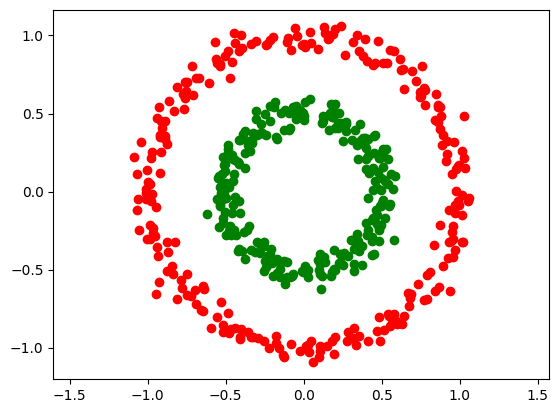

In [ ]:
# Crear el dataset #

# N° de muestras.
n = 500
# N° de Caracteristicas de entrada por muestra.
p = 2

# Generamos dos circulos con cantidad de puntos, tamaño relativo al circulo inferior y una perturbacion aleatoria.
X, Y = make_circles (n_samples=n, factor=0.5, noise=0.05)  #Genera el Dataset #

# Convertimos "Y" en un vector de forma (500,) a una matriz (500, 1).
# np.newaxis agrega una nueva dimensión.
Y = Y[:, np.newaxis]

# Mostramos las muestras de la clase 0.
plt.scatter (X[Y[:, 0] ==0, 0], X[Y[:, 0]==0, 1], c="red" )
# Mostramos las muestras de la clase 1.
plt.scatter (X[Y[:, 0] ==1, 0], X[Y[:, 0]==1, 1], c="green" )
plt.axis("equal")
# Muestra la grafica.
plt.show()


In [ ]:
# Clase de la capa de la red #

class neural_layer():

    # Constructor de la capa.
    # n_conn = numero de conexiones/entradas.
    # n_neur = numero de neuronas.
    # act_f = funcion de activación y su derivada.
  def __init__(self, n_conn, n_neur, act_f):

    # Guardamos la función de activación dentro de la capa.
    self.act_f = act_f

    # Inicializamos aleatoriamente los sesgos entre -1 y 1.
    # La forma es (1, número de neuronas).
    self.b = np.random.rand(1, n_neur)       * 2 - 1

    # Inicializamos aleatoriamente los pesos entre -1 y 1.
    # La forma es (entradas, neuronas).
    self.W = np.random.rand(n_conn, n_neur)  * 2 - 1


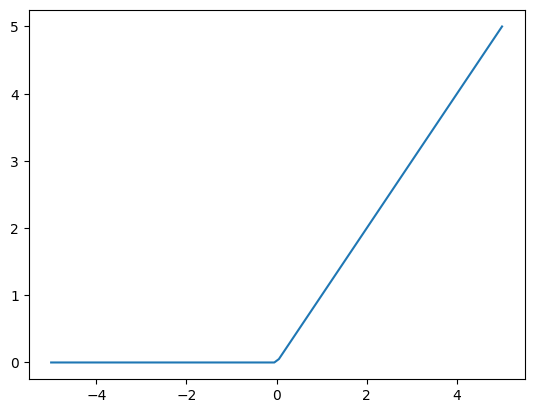

In [ ]:
# Funciones de activiciones #

# Sigmoid transforma cualquier valor real en un valor entre 0 y 1.
# La segunda función corresponde a su derivada expresada
sigm = (lambda x: 1 / (1+np.e ** (-x)),
        lambda x: x * (1-x))

# devuelve 0 para valores negativos y x para valores positivos.
relu = lambda x: np.maximum(0,x)

# Creamos 100 puntos entre -5 y 5 para visualizar
_x = np.linspace (-5,5,100)
plt.plot(_x, relu(_x))


In [ ]:
# Creación de una red neuronal #

# Estas dos capas son ejemplos de cómo se puede crear una capa manualmente.

l0 = neural_layer(p, 4, sigm)
l1 = neural_layer(4, 8, sigm)

# Esta función construye automáticamente una red a partir de una topología.
def create_nn(topology, act_f):
   # Lista donde almacenaremos las capas de la red.
   nn = []

   # Recorremos la topología excepto el último elemento.
   for l, layer in enumerate(topology[:-1]):

      # Creamos una capa y la agregamos a la lista.
      nn.append(neural_layer(topology[l], topology[l+1], act_f))

   # Devolvemos la red completa.
   return nn



In [ ]:
# Arquitectura de la red #

# p = 2, por lo que la topología final es:
# 2 entradas -> 4 neuronas -> 8 neuronas -> 1 salida.
# topology indica cuántas neuronas tiene cada nivel de la red.
topology = [p, 4, 8, 1]

# Construimos la red utilizando sigmoid como función de activación.
neural_net = create_nn(topology, sigm)

# Función de costo L2 / MSE
# calcula el error cuadrático medio entre predicción y valor real.
# proporciona la derivada utilizada para el Backward Pass.

l2_cost = (lambda Yp, Yr: np.mean((Yp - Yr) ** 2),
           lambda Yp, Yr: (Yp - Yr))

# Función de entrenamiento


def train(neural_net, X, Y, l2_cost, lr=0.5, train=True):

  # Guardamos la entrada como primera activación.
  # El primer elemento z es None porque X no proviene de una transformación.

  out = [(None, X)]

  #Forward Pass - Propagacion hacia adelante #

  for l, layer in enumerate(neural_net):

    # z representa la combinación lineal de las entradas.
    # Fórmula de una neurona:
    # z = XW + b
    # W = pesos
    # b = sesgos

    z = out[-1][1] @ neural_net[l].W + neural_net[l].b

    # Aplicamos sigmoid:
    # a = sigmoid(z)
    # La función de activación introduce NO LINEALIDAD.

    a = neural_net[l].act_f[0](z)

    # z -> resultado antes de la activación
    # a -> resultado después de la activación

    out.append((z, a))

  # Backward pass - Propagacion hacia atras #

  if train:

      # deltas almacenará los errores propagados hacia atrás.
      # Delta representa, conceptualmente, cuánto contribuye
      # cada neurona al error final.

    deltas = []

    # reversed hace que recorramos las capas desde la última hasta la primera.
    for l in reversed(range(0, len(neural_net))):

      # z correspondiente a la capa actual.
      # out[1] corresponde a la primera capa,
      # out[2] a la segunda, etc.
      z = out [l+1][0]

      # a corresponde a la activación de la capa actual.
      a = out [l+1][1]

      # Si estamos en la última capa necesitamos calcular
      # el error directamente utilizando:
      # función de costo y derivada de la función de activación
      # Conceptualmente: δ = ∂C/∂a * ∂a/∂z
      # Esto viene directamente de la REGLA DE LA CADENA.
      # La regla de la cadena es fundamental en Backpropagation

      if l == len(neural_net) - 1:
        deltas.insert(0, l2_cost[1](a ,Y) * neural_net[l].act_f[1](a))

      # Para una capa oculta no tenemos directamente el error final
      # Por eso propagamos hacia atrás el delta de la siguiente capa
      # Conceptualmente: δ_l = δ_(l+1) W_(l+1)^T * f'(z_l)
      # Esto permite conocer cuánto contribuyó cada neurona de la capa actual al error final.


      else:
        deltas.insert(0, deltas[0] @ _W.T * neural_net[l].act_f[1](a))

      # Guardamos los pesos actuales.
      _W = neural_net[l].W

      # Desenso de Gradiente #

      # np.mean(..., axis=0) calcula el promedio del gradiente de los sesgos sobre las muestras del batch.
      neural_net[l].b = neural_net[l].b - np.mean(deltas[0], axis=0, keepdims=True) * lr

      # out[l][1] contiene las activaciones de la capa anterior.
      # Su transpuesta se multiplica por delta, Esto produce el gradiente de los pesos:
      # ∂C/∂W = A_(l-1)^T · δ_l
      neural_net[l].W = neural_net[l].W -out[l][1].T @ deltas[0] * lr


  # out[-1][1] corresponde a la activación de la última capa.
  # Yp = predicción final de la red neuronal.
  return out[-1][1]


# Ejecucion del entrenamiento
# Ejecutamos un Forward Pass + Backward Pass.

train(neural_net, X, Y, l2_cost, 0.5)
print("")




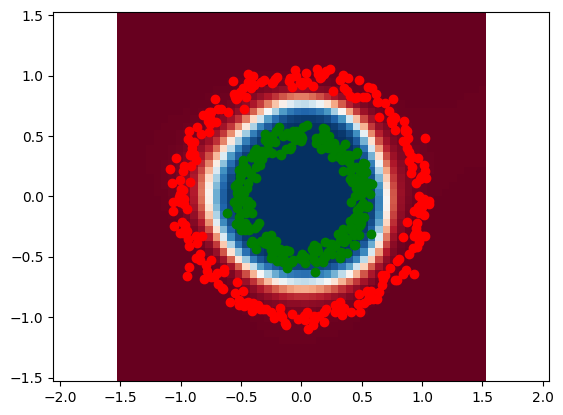

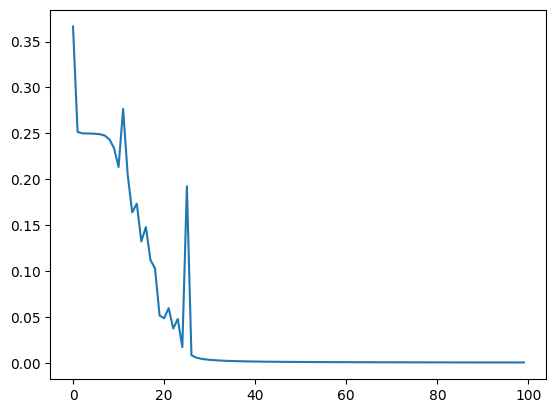

In [ ]:
import time

# clear_output permite limpiar la salida anterior de Jupyter.
from IPython.display import clear_output

# Creamos una nueva red utilizando la topología definida.
neural_n = create_nn(topology, sigm)

# loss almacenará el valor de la función de costo durante el entrenamiento.
loss = []


# Ejecutamos iteraciones de entrenamiento, para este ejercicio 2500.
# Cada iteración realiza:
# 1. Forward Pass
# 2. Cálculo del error
# 3. Backward Pass
# 4. Cálculo de gradientes
# 5. Descenso de gradiente
# 6. Actualización de W y b
# Por lo tanto, train() es el encargado de modificar los
# parámetros de la red en cada iteración.

for i in range(2500):

  # Entrenemos a la red
  # lr=0.05 corresponde al Learning Rate.
  # Un learning rate grande significa que los pesos se odifican mucho en cada iteración.

  pY = train(neural_n, X, Y, l2_cost, lr=0.05)

  #ejecutamos este bloque cada 25 iteraciones.

  if i % 25 == 0:

    print(pY)


    # Calculamos el valor actual de la función de costo.
    # l2_cost[0] corresponde a la función de costo:
    # MSE = mean((Yp - Y)^2)

    loss.append(l2_cost[0](pY, Y))

    # res determina la resolución de la malla que vamos a utilizar para visualizar la predicción de la red.
    res = 50

    # Creamos 50 valores entre -1.5 y 1.5 para el eje X0.
    _x0 = np.linspace(-1.5, 1.5, res)

    # Creamos 50 valores entre -1.5 y 1.5 para el eje X1.
    _x1 = np.linspace(-1.5, 1.5, res)

    _Y = np.zeros((res, res))


    # Recorremos todos los valores posibles de X0 y X1.
    for i0, x0 in enumerate(_x0):
      for i1, x1 in enumerate(_x1):

        #train=False significa: Solo quiero hacer Forward Pass.
        # NO queremos modificar los pesos de la red
        # mientras estamos construyendo la gráfica.
        # La red recibe el punto y devuelve su predicción.

        _Y[i0, i1] = train(neural_n, np.array([[x0, x1]]), Y, l2_cost, train=False)[0][0]


    # Visualizamos la prediccion.

    plt.pcolormesh(_x0, _x1, _Y, cmap="RdBu")
    plt.axis("equal")

    plt.scatter(X[Y[:,0] == 0, 0], X[Y[:,0] == 0, 1], c="red")
    plt.scatter(X[Y[:,0] == 1, 0], X[Y[:,0] == 1, 1], c="green")

    clear_output(wait=True)
    plt.show()
    plt.plot(range(len(loss)), loss)
    plt.show()
    time.sleep(0.5)

# Programación de una red neuronal de una sola capa


Una red neuronal de una sola capa tiene una única capa
entrenable entre la entrada y la salida.

En este ejercicio tenemos:
2 entradas → 1 neurona de salida

La transformación lineal se calcula mediante:

     Z = XW + b

 Posteriormente aplicamos la función de activación sigmoid:

     A = σ(Z)

 En este ejercicio utilizamos:

     - NumPy para las operaciones matriciales.
     - Sigmoid como función de activación.
     - Binary Cross Entropy como función de costo.
     - Backward Pass para calcular los gradientes.
     - Descenso de gradiente para actualizar W y b.

De esta manera podemos observar cómo una neurona aprende a partir de los datos y cómo sus pesos (W) y sesgo (b) se ajustan durante el entrenamiento.

In [ ]:
# Libreria que permite trabajar con vectores, matrices y operaciones numericas.
import numpy as np

#Datos
#Columna 0 son Area
#Columna 1 son Precio

X = np.array([
    [50, 180],
    [60, 200],
    [80, 190],
    [90, 220],
    [100, 210],
    [55, 250],
    [85, 200],
    [70, 240]
], dtype=float)

#Valor Esperado
# 0 No es buena inversión
# 1 Es buena inversión

Y = np.array([
    [0],
    [0],
    [1],
    [1],
    [1],
    [0],
    [1],
    [0]
], dtype=float)

#Normalizacion
X = X / np.max(X, axis=0)

#Paramentros de la Red
W = np.zeros((2, 1))

# sesgos de la neurona
b = 0.0


# Learning Rate
# Determina qué tan grandes serán los cambios
lr = 0.1

#Funcion Sigmoid

def sigmoid(z):

    return 1 / (1 + np.exp(-z))

# Funcion de Costo

def binary_cross_entropy(Y, Y_pred):

    return -np.mean(
        Y * np.log(Y_pred)
        +
        (1 - Y) * np.log(1 - Y_pred)
    )


In [ ]:
#Entrenamiento

epochs = 1000

loss_history = []


for epoch in range(epochs):

# Forward Pass

  Z = X @ W + b

  Y_pred = sigmoid(Z)

# Funcion de Costo

  loss = binary_cross_entropy(Y, Y_pred)

  loss_history.append(loss)

# Backward Pass

  error = Y_pred - Y

  dW = X.T @ error / len(X)

  db = np.mean(error)

# Descenso de Gradiente

  W = W - lr * dW

  b = b - lr * db

# Progreso

  if epoch % 100 == 0:

        print(
            f"Epoch: {epoch} | Loss: {loss:.6f}"
        )

# Prediccion Final

Z = X @ W + b

Y_pred = sigmoid(Z)


# Convertimos probabilidad a clase
# >= 0.5 -> 1
# <  0.5 -> 0

Y_class = (Y_pred >= 0.5).astype(int)



print("\nRESULTADO FINAL")

print("\nEsperado:")
print(Y.T)

print("\nProbabilidad predicha:")
print(Y_pred.T)

print("\nClase predicha:")
print(Y_class.T)

print("\nError:")
print((Y - Y_class).T)

print("\nPesos finales:")
print(W)

print("\nSesgo final:")
print(b)

print("\nLoss final:")
print(loss)

Epoch: 0 | Loss: 0.693147
Epoch: 100 | Loss: 0.646217
Epoch: 200 | Loss: 0.604975
Epoch: 300 | Loss: 0.568059
Epoch: 400 | Loss: 0.534952
Epoch: 500 | Loss: 0.505191
Epoch: 600 | Loss: 0.478365
Epoch: 700 | Loss: 0.454112
Epoch: 800 | Loss: 0.432118
Epoch: 900 | Loss: 0.412110

RESULTADO FINAL

Esperado:
[[0. 0. 1. 1. 1. 0. 1. 0.]]

Probabilidad predicha:
[[0.31511666 0.38023927 0.63123285 0.67594159 0.78469739 0.23631043
  0.66405015 0.40589572]]

Clase predicha:
[[0 0 1 1 1 0 1 0]]

Error:
[[0. 0. 0. 0. 0. 0. 0. 0.]]

Pesos finales:
[[ 4.67971427]
 [-2.25248272]]

Sesgo final:
-1.494375169250386

Loss final:
0.39402546595791377


# Programación de perceptrón
El perceptron es una de las unidades fundamentales de laas redes neuronales artificiales
En este ejercicio se utiliza un perceptrón para clasificar propiedades inmobiliarias utilizando dos características:

    X = [Área, Precio]

La combinación lineal se calcula mediante:

    Z = XW + b

Posteriormente se utiliza una función escalón para obtener una clasificación binaria:

    Y_pred = 1  si Z >= 0
    Y_pred = 0  si Z < 0

 Durante el entrenamiento, el perceptrón compara la predicción con el valor esperado y utiliza el error para actualizar sus parámetros:

    W = W + η Xᵀ(Y - Y_pred)
    b = b + η Σ(Y - Y_pred)

 Donde:

    W → pesos
    b → sesgo (bias)
    η → learning rate

En este ejercicio se busca comprender qué ocurre dentro de un perceptrón sin utilizar librerías de Machine Learning que oculten su funcionamiento.


In [ ]:
# Libreria que permite trabajar con vectores, matrices y operaciones numericas.
import numpy as np

# Crea graficos y visualizacion de datos.
import matplotlib.pyplot as plt

# Cada fila representa una propiedad.
# Columna 0 -> área
# Columna 1 -> precio

X = np.array([
    [50, 180],
    [60, 200],
    [80, 190],
    [90, 220],
    [100, 210],
    [55, 250],
    [85, 200],
    [70, 240]
])

# 0 NO comprar
# 1 Comprar

Y = np.array([
    [0],
    [0],
    [1],
    [1],
    [1],
    [0],
    [1],
    [0]
])

# Normalizamos los datos, para facilitar el trabajo del algoritmo

X = X / np.max(X, axis=0)

print("Datos normalizados:")
print(X)


Datos normalizados:
[[0.5  0.72]
 [0.6  0.8 ]
 [0.8  0.76]
 [0.9  0.88]
 [1.   0.84]
 [0.55 1.  ]
 [0.85 0.8 ]
 [0.7  0.96]]


In [ ]:
# Inicializamos el perceptron #

# Inicializamos los pesos en cero.
W = np.zeros((2, 1))


# sesgo inicial
b = 0


# Learning Rate
lr = 0.1


print("Pesos iniciales:", W)
print("sesgo inicial:", b)

# Forward Pass operacion fundamental

Z = X @ W + b

# Funcion Escalon

def escalon(Z):

    return (Z >= 0).astype(int)

Pesos iniciales: [[0.]
 [0.]]
sesgo inicial: 0


In [ ]:
# Entrenamiento del Perceptron

# Epocas- Establece cuantas veces el perceptron va recorrer y entrenar el conjunto de datos
epochs = 40

for epoch in range(epochs):

    # Forward Pass

    Z = X @ W + b

    Y_pred = escalon(Z)


    # Calcula error

    error = Y - Y_pred


    # Actualiza Pesos

    W = W + lr * X.T @ error


    # Actualiza Sesgo


    b = b + lr * np.sum(error)

    # Mostrar Informacion, lineas comentadas.
    #print(f"\nÉpoca: {epoch + 1}")
    #print("Predicciones:")
    #print(Y_pred.T)
    #print("Error:")
    #print(error.T)
    #print("W:")
    #print(W.T)
    #print("b:")
    #print(b)


# Evaluacion final

    # Forward Pass - Propagacion hacia adelante

    Z = X @ W + b

Y_pred = escalon(Z)


print("RESULTADO FINAL")

print("\nEsperado:")
print(Y.T)

print("\nPredicción:")
print(Y_pred.T)

print("\nError:")
print((Y - Y_pred).T)

print("\nPesos finales:")
print(W)

print("\nSesgo final:")
print(b)

RESULTADO FINAL

Esperado:
[[0 0 1 1 1 0 1 0]]

Predicción:
[[0 0 1 1 1 0 1 0]]

Error:
[[0 0 0 0 0 0 0 0]]

Pesos finales:
[[ 1.63 ]
 [-0.872]]

Sesgo final:
-0.5999999999999999


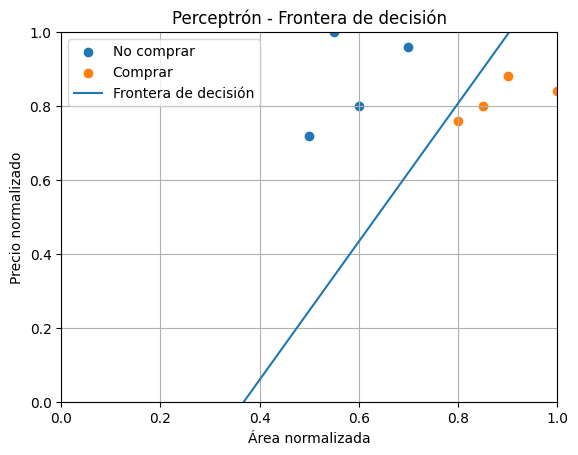

In [ ]:

# Pesos finales aprendidos por el preceptron


w1 = W[0, 0]      # Peso correspondiente al área
w2 = W[1, 0]      # Peso correspondiente al precio
b = b             # Bias aprendido

# Frontera de Desicion


# El perceptrón decide:
# Clase 1 si: w1*x1 + w2*x2 + b >= 0
# La frontera se encuentra cuando: w1*x1 + w2*x2 + b = 0
# Despejamos x2: x2 = -(w1*x1 + b) / w2

x1 = np.linspace(0, 1, 100)

x2 = -(w1 * x1 + b) / w2


# Graficar las propiedades


# Propiedades de clase 0
plt.scatter(
    X[Y[:, 0] == 0, 0],
    X[Y[:, 0] == 0, 1],
    label="No comprar"
)


# Propiedades de clase 1
plt.scatter(
    X[Y[:, 0] == 1, 0],
    X[Y[:, 0] == 1, 1],
    label="Comprar"
)


# Graficar la frontera

plt.plot(
    x1,
    x2,
    label="Frontera de decisión"
)


# Configuracion de la grafica

plt.xlabel("Área normalizada")
plt.ylabel("Precio normalizado")

plt.title("Perceptrón - Frontera de decisión")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.grid()
plt.legend()

plt.show()